4 violin patches before shift


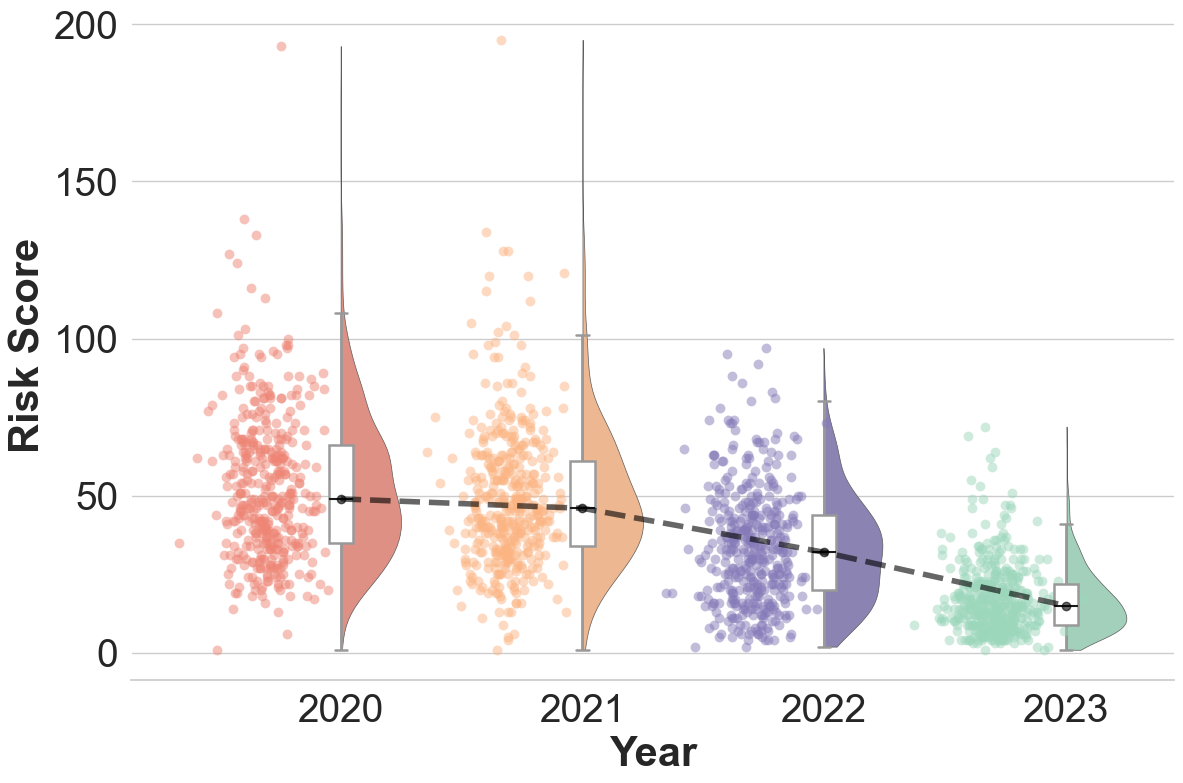

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略所有的 FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)


df_risk_scores = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')

df_info = pd.read_excel('./Data/S&P500_List_2025.xlsx')
df_info = df_info[['Symbol', 'GICS_Sector']]
df_info = df_info[df_info['Symbol'].isin(df_risk_scores['ticker'])]

df = pd.merge(df_risk_scores, df_info,
                     how='left',
                     left_on='ticker',
                     right_on='Symbol')[['year', 'risk_score']]

cats = [2020, 2021, 2022, 2023]

# -----------------------------
# 2. 颜色 & 基本风格
# -----------------------------

palette = ["#EE8575", "#FBB482", "#867bb9", "#9cd7bc"]
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))

# -----------------------------
# 3. 画完整 violin，再裁成半边
# -----------------------------
vp = sns.violinplot(
    x="year", y="risk_score", data=df,
    palette=palette, ax=ax, cut=0, inner='box', alpha=1, linewidth=0.5, width=0.5,
)

shift_amount = -0.01
print(len(vp.collections), "violin patches before shift")

# 将每条 violin 的 patch 剪掉左半边
for index, violin in enumerate(vp.collections):
    # 复制 Path，方便操作
    path = violin.get_paths()[0]
    verts = path.vertices
    # verts[:,0] 是 X 坐标，取中位数（竖向 violin 的中心线）
    mid_x = np.median(verts[:, 0])
    # 保留 verts.x >= mid_x 这一半
    verts[:,0] = np.where(verts[:,0] < mid_x, mid_x, verts[:,0])
    # 2. 【新增】将所有顶点的 X 坐标向右平移指定的距离
    if index == 2:
        verts[:, 0] += -0.01
    if index == 3:
        verts[:, 0] += -0.001

# -----------------------------
# 4. 叠 boxplot
# -----------------------------
sns.boxplot(
    x="year", y="risk_score", data=df,
    width=0.1, ax=ax, showcaps=True,
    capprops={"zorder":4, "linewidth":1.8},
    boxprops={"zorder":4, "linewidth":1.8},
    whiskerprops={"linewidth":2}, 
    medianprops={"linewidth":1.5, "color":"k", "zorder":4},
    showfliers=False, palette=["white"]*4,
)

# -----------------------------
# 5. 叠散点（只在左半边）
# -----------------------------
offset = 0.3          # 散点整体向左移动的量，≈小提琴宽度的一半
jitter = 0.1         # 额外随机抖动，避免画成一条竖线

for i, cat in enumerate(cats):
    y_vals = df.loc[df["year"] == cat, "risk_score"]
    # 以类别索引 (i) 为中心，整体向左 offset，再加一点随机 jitter
    x_vals = np.random.normal(loc=i - offset, scale=jitter, size=len(y_vals))
    ax.scatter(
        x_vals, y_vals,
        s=50, alpha=0.5, color=palette[i], zorder=3, linewidth=0
    )

# -----------------------------
# 6. 趋势线
# -----------------------------

mean_scores = df_risk_scores.groupby('year')['risk_score'].quantile(0.5).reindex(cats)

# 在图上绘制均值趋势线
# 我们使用 plt.plot 来创建线条。x轴需要是数值位置（0, 1, 2...），y轴是均值。
ax.plot(range(len(mean_scores)), mean_scores,
         color="#00000099",           # 线条颜色
         marker='o',            # 标记点样式
         linestyle='dashed',       # 线条样式
         linewidth=4,           # 线条宽度
         label='年度均值',
         zorder=5)      # 图例标签

# -----------------------------
# 6. 美化坐标轴
# -----------------------------
ax.set_xlabel("Year", fontsize=30, fontweight='bold')
ax.set_ylabel("Risk Score", fontsize=30, fontweight='bold')
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, fontsize=28)
ax.set_yticks(np.arange(0, 201, 50))  # 设置y轴刻度
ax.set_yticklabels(np.arange(0, 201, 50), fontsize=28)
sns.despine(left=True)

plt.tight_layout()
fig.savefig('yearly_risk_trend.pdf', dpi=600)
plt.show()